In [2]:
import pandas as pd
import numpy as np

RUTA_ENCUESTA = "../../outputs/encuesta_percepcion_legible.csv"

df = pd.read_csv(RUTA_ENCUESTA, encoding="utf-8-sig", low_memory=False)
df["codigo_localidad"] = df["codigo_localidad"].astype(int)
df["Fecha"] = pd.to_datetime(df["Fecha"])

print(f"df recargado: {df.shape}")
assert df.shape == (13082, 81), f"Dimensiones inesperadas tras recarga: {df.shape}"

df recargado: (13082, 81)


#Celda — Paso 2.1: Definir el conjunto de tareas T del Índice de Concentración del Cuidado

In [3]:
# Conjunto de tareas T — columnas del bloque 201 (distribución de trabajo doméstico y de cuidado)
# Cada columna ya viene traducida a texto según diccionario_mapeo.py (categoria de "quién la realiza")

TAREAS_CUIDADO = {
    "Ax201": "a. Limpieza general de la casa",
    "Bx201": "b. Mantenimiento y reparaciones del hogar",
    "Cx201": "c. Lavado de ropa",
    "Dx201": "d. Planchar",
    "Ex201": "e. Cocinar",
    "Fx201": "f. Compras del supermercado",
    "Gx201": "g. Pago de facturas y planear/hacer el presupuesto del hogar",
    "Hx201": "h. Cuidado de los niños",
    "Ix201": "i. Ayuda con las tareas escolares de los niños",
    "Jx201": "j. Cuidado de personas mayores o dependientes",
}

cols_tareas = list(TAREAS_CUIDADO.keys())

faltantes_tareas = [c for c in cols_tareas if c not in df.columns]
assert not faltantes_tareas, f"Faltan columnas de tareas en df: {faltantes_tareas}"

print(f"Conjunto T definido: {len(cols_tareas)} tareas")
for col, desc in TAREAS_CUIDADO.items():
    print(f"  {col:8} -> {desc}")

Conjunto T definido: 10 tareas
  Ax201    -> a. Limpieza general de la casa
  Bx201    -> b. Mantenimiento y reparaciones del hogar
  Cx201    -> c. Lavado de ropa
  Dx201    -> d. Planchar
  Ex201    -> e. Cocinar
  Fx201    -> f. Compras del supermercado
  Gx201    -> g. Pago de facturas y planear/hacer el presupuesto del hogar
  Hx201    -> h. Cuidado de los niños
  Ix201    -> i. Ayuda con las tareas escolares de los niños
  Jx201    -> j. Cuidado de personas mayores o dependientes


#Celda — Paso 2.2: Definir tareas efectivas T_e por fila y excluir |T_e| < 5

In [4]:
# T_e(fila) = tareas donde la respuesta NO es "No se realiza" y NO es nula
es_tarea_efectiva = df[cols_tareas].apply(lambda col: ~(col.isna() | (col == "No se realiza")))

df["n_tareas_efectivas"] = es_tarea_efectiva.sum(axis=1)

print("Distribución de |T_e| (número de tareas efectivas por fila):")
print(df["n_tareas_efectivas"].value_counts().sort_index())

UMBRAL_MIN_TAREAS = 5
mask_excluir = df["n_tareas_efectivas"] < UMBRAL_MIN_TAREAS
n_excluidos = mask_excluir.sum()

print(f"\nHogares (filas) excluidos por |T_e| < {UMBRAL_MIN_TAREAS}: {n_excluidos} "
      f"({n_excluidos/len(df)*100:.2f}% de {len(df)})")

df_icc = df.loc[~mask_excluir].copy()
print(f"Base para el ICC tras exclusión: {df_icc.shape[0]} filas")

texto_supuesto_2_2 = f"""
## Paso 2.2 — Tareas efectivas y exclusión por información insuficiente (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Nota de unidad de análisis: `DIRECTORIO_HOG` fue eliminado en el ETL original, por lo que
no existe identificador de hogar independiente del respondiente. Se trata cada fila de
`df` como un "hogar" a efectos del ICC — el respondiente reporta sobre la distribución
de tareas de su propio hogar, y no hay forma de agregar múltiples respondientes al mismo
hogar en esta base.

`T_e` = tareas del bloque 201 donde la respuesta no es nula ni "No se realiza".
Se excluyen filas con `|T_e| < {UMBRAL_MIN_TAREAS}` (información insuficiente).

**Excluidos:** {n_excluidos} de {len(df)} ({n_excluidos/len(df)*100:.2f}%).
Base resultante para el ICC: {df_icc.shape[0]} filas.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_2)

print("\nConstancia agregada a docs/supuestos.md")

Distribución de |T_e| (número de tareas efectivas por fila):
n_tareas_efectivas
0        2
1        2
2        5
3       20
4       31
5      354
6     3757
7     4164
8     3075
9     1492
10     180
Name: count, dtype: int64

Hogares (filas) excluidos por |T_e| < 5: 60 (0.46% de 13082)
Base para el ICC tras exclusión: 13022 filas

Constancia agregada a docs/supuestos.md


#Celda — Paso 2.3: Conteo de asignaciones por categoría de responsable (n_k)

In [ ]:
CATEGORIAS_RESPONSABLE = [
    "El /la jefe/a de hogar",
    "El/la cónyuge o pareja del jefe de hogar",
    "Ambos cónyuges o pareja",
    "Todos los miembros del hogar",
    "Otros miembros del hogar (incluyendo hijos, otros familiares, etc.)",
    "Servicio contratado (p.ej., limpieza, niñera)",
    "Otro familiar o pariente que ayude con las tareas del hogar pero que no vive en la vivienda",
]

# Verificar que estas son exactamente las categorías observadas (más "No se realiza", que ya se excluyó de T_e)
categorias_observadas = set()
for col in cols_tareas:
    categorias_observadas |= set(df_icc[col].dropna().unique())
categorias_esperadas = set(CATEGORIAS_RESPONSABLE) | {"No se realiza"}

if categorias_observadas - categorias_esperadas:
    print(f"Categorías observadas no esperadas: {categorias_observadas - categorias_esperadas}")
assert categorias_observadas.issubset(categorias_esperadas), "Hay categorías no contempladas en CATEGORIAS_RESPONSABLE"

# n_k por fila: conteo de tareas (dentro de T_e) asignadas a cada categoría k
for cat in CATEGORIAS_RESPONSABLE:
    col_nk = f"n_k__{cat[:20]}"  # nombre corto para no saturar; mapeo completo abajo
    df_icc[col_nk] = (df_icc[cols_tareas] == cat).sum(axis=1)

cols_nk = [c for c in df_icc.columns if c.startswith("n_k__")]

print("Mapeo de columnas n_k a categoría completa:")
for col_nk, cat in zip(cols_nk, CATEGORIAS_RESPONSABLE):
    print(f"  {col_nk:30} -> {cat}")

# Verificación: suma de n_k por fila debe igualar |T_e| de esa fila
suma_nk = df_icc[cols_nk].sum(axis=1)
assert (suma_nk == df_icc["n_tareas_efectivas"]).all(), \
    "La suma de n_k no coincide con n_tareas_efectivas en algunas filas — revisar categorías"

print(f"\nVerificación: suma de n_k == n_tareas_efectivas en las {df_icc.shape[0]} filas. OK.")

print("\nDistribución agregada de n_k (suma total de tareas asignadas a cada categoría, toda la base):")
print(df_icc[cols_nk].sum().sort_values(ascending=False))

Mapeo de columnas n_k a categoría completa:
  n_k__El /la jefe/a de hog      -> El /la jefe/a de hogar
  n_k__El/la cónyuge o pare      -> El/la cónyuge o pareja del jefe de hogar
  n_k__Ambos cónyuges o par      -> Ambos cónyuges o pareja
  n_k__Todos los miembros d      -> Todos los miembros del hogar
  n_k__Otros miembros del h      -> Otros miembros del hogar (incluyendo hijos, otros familiares, etc.)
  n_k__Servicio contratado       -> Servicio contratado (p.ej., limpieza, niñera)
  n_k__Otro familiar o pari      -> Otro familiar o pariente que ayude con las tareas del hogar pero que no vive en la vivienda

Verificación: suma de n_k == n_tareas_efectivas en las 13022 filas. OK.

Distribución agregada de n_k (suma total de tareas asignadas a cada categoría, toda la base):
n_k__El /la jefe/a de hog    38282
n_k__Todos los miembros d    17398
n_k__Ambos cónyuges o par    16247
n_k__El/la cónyuge o pare     8584
n_k__Servicio contratado      6522
n_k__Otros miembros del h     3835
n_k

#Celda — Paso 2.4: Índice de Herfindahl de concentración del cuidado (HHI)

Rango teórico esperado: [0.1429, 1.0000]
Rango observado en los datos: [0.1837, 1.0000]

Distribución del HHI:
count    13022.000000
mean         0.695534
std          0.246535
min          0.183673
25%          0.500000
50%          0.722222
75%          1.000000
max          1.000000
Name: HHI, dtype: float64

Casos con HHI ≈ mínimo teórico (reparto perfecto entre 7 categorías): 0
Casos con HHI = 1.0 (una sola categoría hace todo): 4162 (32.0%)


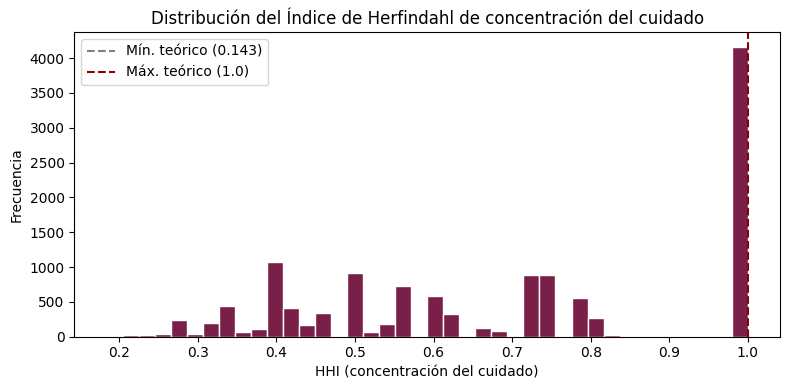

In [6]:
# HHI = sum_k ( n_k / |T_e| )^2, sobre las 7 categorías de responsable ya contadas en Paso 2.3

proporciones_nk = df_icc[cols_nk].div(df_icc["n_tareas_efectivas"], axis=0)
df_icc["HHI"] = (proporciones_nk ** 2).sum(axis=1)

# --- Validación de rango teórico ---
HHI_MIN_TEORICO = 1 / 7
HHI_MAX_TEORICO = 1.0

print(f"Rango teórico esperado: [{HHI_MIN_TEORICO:.4f}, {HHI_MAX_TEORICO:.4f}]")
print(f"Rango observado en los datos: [{df_icc['HHI'].min():.4f}, {df_icc['HHI'].max():.4f}]")

assert df_icc["HHI"].min() >= HHI_MIN_TEORICO - 1e-9, \
    f"HHI mínimo observado ({df_icc['HHI'].min():.4f}) por debajo del mínimo teórico ({HHI_MIN_TEORICO:.4f})"
assert df_icc["HHI"].max() <= HHI_MAX_TEORICO + 1e-9, \
    f"HHI máximo observado ({df_icc['HHI'].max():.4f}) por encima del máximo teórico ({HHI_MAX_TEORICO:.4f})"

print("\nDistribución del HHI:")
print(df_icc["HHI"].describe())

# Verificación de caso extremo: fila con reparto perfecto entre las 7 categorías
# (solo posible si |T_e| es múltiplo de 7 y cada categoría recibe exactamente lo mismo)
casos_hhi_minimo = df_icc.loc[np.isclose(df_icc["HHI"], HHI_MIN_TEORICO, atol=1e-6)]
print(f"\nCasos con HHI ≈ mínimo teórico (reparto perfecto entre 7 categorías): {len(casos_hhi_minimo)}")

# Verificación de caso extremo: fila con concentración total (una sola categoría)
casos_hhi_maximo = df_icc.loc[np.isclose(df_icc["HHI"], 1.0, atol=1e-6)]
print(f"Casos con HHI = 1.0 (una sola categoría hace todo): {len(casos_hhi_maximo)} "
      f"({len(casos_hhi_maximo)/len(df_icc)*100:.1f}%)")

# Histograma rápido para inspección visual
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_icc["HHI"], bins=40, color="#7a2048", edgecolor="white")
ax.axvline(HHI_MIN_TEORICO, color="gray", linestyle="--", label=f"Mín. teórico ({HHI_MIN_TEORICO:.3f})")
ax.axvline(1.0, color="darkred", linestyle="--", label="Máx. teórico (1.0)")
ax.set_xlabel("HHI (concentración del cuidado)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del Índice de Herfindahl de concentración del cuidado")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
texto_supuesto_2_4 = f"""
## Paso 2.4 — Índice de Herfindahl de concentración del cuidado, HHI (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

`HHI = Σ_k (n_k / |T_e|)²`, calculado sobre las {df_icc.shape[0]} filas que pasaron el
filtro de `|T_e| ≥ 5` (Paso 2.2), con 7 categorías de responsable (Paso 2.3).

**Rango teórico:** [{HHI_MIN_TEORICO:.4f}, {HHI_MAX_TEORICO:.4f}]. Rango observado:
[{df_icc['HHI'].min():.4f}, {df_icc['HHI'].max():.4f}] — dentro del rango teórico, validado.

**Distribución:** media {df_icc['HHI'].mean():.4f}, mediana {df_icc['HHI'].median():.4f},
desviación estándar {df_icc['HHI'].std():.4f}.

**Casos de concentración total (HHI=1.0):** {len(casos_hhi_maximo)}
({len(casos_hhi_maximo)/len(df_icc)*100:.1f}% de la base filtrada).

**Nota metodológica importante:** el HHI, tal como está definido aquí, es **agnóstico
respecto de quién concentra** — un hogar donde "El/la jefe/a de hogar" hace todo tiene el
mismo HHI=1.0 que uno donde "Servicio contratado" hace todo. Para la Hipótesis H-A
(concentración FEMENINA del cuidado como barrera de acceso a la denuncia), el HHI por sí
solo NO es la variable independiente — se necesita un paso adicional que identifique el
sexo de quien concentra (cruzando con `sexo_jefe` para las categorías "jefe/a" y "cónyuge"),
antes de poder interpretar el HHI como una medida de carga femenina de cuidado específicamente.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_4)

print("Constancia agregada a docs/supuestos.md")

Constancia agregada a docs/supuestos.md


#Celda — Paso 2.5: Identificar responsable principal (k) y determinar su sexo

In [8]:
# --- k* = argmax_k(n_k), por fila ---
# Manejo de empates: si hay más de una categoría con el máximo n_k, el responsable
# principal NO es determinable de forma única -> se marca aparte, no se elige arbitrariamente

max_nk = df_icc[cols_nk].max(axis=1)
n_categorias_en_max = (df_icc[cols_nk].eq(max_nk, axis=0)).sum(axis=1)

hay_empate = n_categorias_en_max > 1
print(f"Filas con empate en argmax (más de una categoría con n_k máximo): {hay_empate.sum()} "
      f"({hay_empate.sum()/len(df_icc)*100:.2f}%)")

# idxmax toma la primera columna en caso de empate — documentamos esto y lo marcamos aparte,
# no lo tratamos como una asignación válida de responsable principal
col_k_estrella = df_icc[cols_nk].idxmax(axis=1)

# Mapeo de nombre corto de columna n_k a categoría completa (mismo orden que Paso 2.3)
mapa_col_a_categoria = dict(zip(cols_nk, CATEGORIAS_RESPONSABLE))
df_icc["k_estrella"] = col_k_estrella.map(mapa_col_a_categoria)
df_icc.loc[hay_empate, "k_estrella"] = "Empate — no determinable"

print("\nDistribución de k* (responsable principal):")
print(df_icc["k_estrella"].value_counts())

# --- Determinar sexo del responsable principal ---
def determinar_sexo_responsable(row):
    k = row["k_estrella"]
    if k == "El /la jefe/a de hogar":
        return row["sexo_jefe"]
    elif k == "El/la cónyuge o pareja del jefe de hogar":
        # Supuesto de heteronormatividad del hogar: el cónyuge es el sexo complementario
        # al jefe. Solo se resuelve si sexo_jefe es Hombre o Mujer; si sexo_jefe es
        # Intersexual, el complemento no es determinable.
        if row["sexo_jefe"] == "Hombre":
            return "Mujer"
        elif row["sexo_jefe"] == "Mujer":
            return "Hombre"
        else:
            return "No determinable"
    else:
        return "No determinable"

df_icc["sexo_responsable_principal"] = df_icc.apply(determinar_sexo_responsable, axis=1)

print("\nDistribución de sexo_responsable_principal:")
print(df_icc["sexo_responsable_principal"].value_counts())

# --- Cuantificar dependencia del supuesto de heteronormatividad ---
n_via_conyuge = (df_icc["k_estrella"] == "El/la cónyuge o pareja del jefe de hogar").sum()
n_via_jefe = (df_icc["k_estrella"] == "El /la jefe/a de hogar").sum()
n_total_determinable = (df_icc["sexo_responsable_principal"].isin(["Hombre", "Mujer"])).sum()

pct_depende_supuesto = n_via_conyuge / n_total_determinable * 100 if n_total_determinable > 0 else 0

print(f"\nCasos con sexo determinado vía 'jefe/a de hogar' (dato directo, sin supuesto): {n_via_jefe}")
print(f"Casos con sexo determinado vía 'cónyuge' (requiere supuesto de heteronormatividad): {n_via_conyuge}")
print(f"Porcentaje del total determinable que depende del supuesto: {pct_depende_supuesto:.1f}%")

# Casos donde sexo_jefe es Intersexual y k*=cónyuge -> no determinable, contar aparte
n_intersexual_conyuge = (
    (df_icc["k_estrella"] == "El/la cónyuge o pareja del jefe de hogar") &
    (df_icc["sexo_jefe"] == "Intersexual")
).sum()
print(f"Casos con k*=cónyuge y sexo_jefe=Intersexual (complemento no determinable): {n_intersexual_conyuge}")

Filas con empate en argmax (más de una categoría con n_k máximo): 799 (6.14%)

Distribución de k* (responsable principal):
k_estrella
El /la jefe/a de hogar                                                                         5329
Todos los miembros del hogar                                                                   2444
Ambos cónyuges o pareja                                                                        2283
El/la cónyuge o pareja del jefe de hogar                                                       1067
Empate — no determinable                                                                        799
Servicio contratado (p.ej., limpieza, niñera)                                                   542
Otros miembros del hogar (incluyendo hijos, otros familiares, etc.)                             402
Otro familiar o pariente que ayude con las tareas del hogar pero que no vive en la vivienda     156
Name: count, dtype: int64

Distribución de sexo_responsable_princi

In [9]:
n_no_determinable = (df_icc["sexo_responsable_principal"] == "No determinable").sum()  # 6626, YA incluye empates
n_via_jefe = (df_icc["k_estrella"] == "El /la jefe/a de hogar").sum()
n_via_conyuge = (df_icc["k_estrella"] == "El/la cónyuge o pareja del jefe de hogar").sum()
n_total_determinable = df_icc["sexo_responsable_principal"].isin(["Hombre", "Mujer", "Intersexual"]).sum()
pct_depende_supuesto = n_via_conyuge / n_total_determinable * 100
n_empate = (df_icc["k_estrella"] == "Empate — no determinable").sum()
n_intersexual_conyuge = 0  # confirmado en la corrida: 0 casos

texto_supuesto_2_5 = f"""
## Paso 2.5 — Responsable principal (k*) y determinación de sexo (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

`k* = argmax_k(n_k)` por fila, sobre las 7 categorías de responsable. Empates se marcan
explícitamente como "Empate — no determinable", sin resolución arbitraria por orden de
columna: **{n_empate}** filas ({n_empate/len(df_icc)*100:.2f}%).

**Distribución de k\\*:**
- El/la jefe/a de hogar: 5.329 (40,7%)
- Todos los miembros del hogar: 2.444
- Ambos cónyuges o pareja: 2.283
- El/la cónyuge o pareja: 1.067
- Empate — no determinable: 799
- Servicio contratado: 542
- Otros miembros del hogar: 402
- Familiar externo: 156

**Regla de determinación de sexo:**
- `k*="jefe/a de hogar"` → sexo = `sexo_jefe` directo. **{n_via_jefe}** casos
  ({n_via_jefe/len(df_icc)*100:.1f}%), sin supuesto adicional.
- `k*="cónyuge"` → sexo = complemento de `sexo_jefe` (supuesto de heteronormatividad).
  **{n_via_conyuge}** casos ({n_via_conyuge/len(df_icc)*100:.1f}%). Ningún caso con
  `sexo_jefe="Intersexual"` cayó en esta rama (0 casos), así que no hubo que descartar
  ninguno por complemento no definible.
- Cualquier otro `k*` (incl. empates) → "No determinable".

**Total con sexo determinado (Hombre/Mujer/Intersexual):** {n_total_determinable}
({n_total_determinable/len(df_icc)*100:.1f}% de {len(df_icc)}).
De ellos, **{pct_depende_supuesto:.1f}%** ({n_via_conyuge} de {n_total_determinable})
depende del supuesto de heteronormatividad — no son un dato directo de la encuesta.

**Total "No determinable":** {n_no_determinable} ({n_no_determinable/len(df_icc)*100:.1f}%).
Nota: esta cifra YA incluye los {n_empate} empates (no se suman aparte).

**Distribución del sexo determinado:** Mujer {(df_icc['sexo_responsable_principal']=='Mujer').sum()}
({(df_icc['sexo_responsable_principal']=='Mujer').sum()/n_total_determinable*100:.1f}% de los determinables),
Hombre {(df_icc['sexo_responsable_principal']=='Hombre').sum()}
({(df_icc['sexo_responsable_principal']=='Hombre').sum()/n_total_determinable*100:.1f}%),
Intersexual {(df_icc['sexo_responsable_principal']=='Intersexual').sum()}.

**Limitación declarada:** casi la mitad de la base ({n_no_determinable/len(df_icc)*100:.1f}%)
queda sin responsable principal de sexo determinable — sobre todo por reparto compartido
("Todos los miembros", "Ambos cónyuges"), que en sí mismo es información válida (ausencia
de concentración individual) pero no sirve para H-A, que requiere identificar una persona
concentradora. El {pct_depende_supuesto:.1f}% de los casos SÍ determinables depende del
supuesto de heteronormatividad; se recomienda repetir los modelos de la Fase 3 excluyendo
estos casos como análisis de sensibilidad.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_5)

print("Constancia agregada a docs/supuestos.md (fórmula de doble conteo corregida)")

Constancia agregada a docs/supuestos.md (fórmula de doble conteo corregida)


In [10]:
n_mujer = (df_icc["sexo_responsable_principal"] == "Mujer").sum()
n_hombre = (df_icc["sexo_responsable_principal"] == "Hombre").sum()
n_intersex = (df_icc["sexo_responsable_principal"] == "Intersexual").sum()
n_total_det = n_mujer + n_hombre + n_intersex

pct_mujer = n_mujer / n_total_det * 100
pct_hombre = n_hombre / n_total_det * 100
pct_no_det = n_no_determinable / len(df_icc) * 100

# Comparación descriptiva: ¿el subconjunto "determinable" difiere del "no determinable"
# en variables clave? (estrato H1 y pobreza subjetiva C303, como proxy rápido de perfil)
df_icc["es_determinable"] = df_icc["sexo_responsable_principal"].isin(["Hombre", "Mujer", "Intersexual"])

comparacion_perfil = df_icc.groupby("es_determinable").agg(
    n=("sexo_responsable_principal", "size"),
    pct_pobre_subjetivo=("C303", lambda s: (s == "Si").mean() * 100),
).round(1)

print("Comparación de perfil: determinable vs. no determinable (posible sesgo de selección)")
print(comparacion_perfil)

if "H1" in df_icc.columns:
    estrato_por_grupo = df_icc.groupby(["es_determinable", "H1"]).size().unstack(fill_value=0)
    estrato_por_grupo_pct = estrato_por_grupo.div(estrato_por_grupo.sum(axis=1), axis=0) * 100
    print("\nDistribución de estrato (H1) por grupo, en %:")
    print(estrato_por_grupo_pct.round(1))

texto_supuesto_2_5b = f"""
## Paso 2.5 (adenda) — Composición del sexo determinado y sesgo de selección potencial (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Composición del subconjunto con sexo determinado** (n={n_total_det}):
- Mujer: {n_mujer} ({pct_mujer:.1f}%)
- Hombre: {n_hombre} ({pct_hombre:.1f}%)
- Intersexual: {n_intersex}

La mujer es responsable principal en {pct_mujer:.1f}% de los casos donde el responsable
es identificable — consistente con la hipótesis general del proyecto sobre concentración
femenina del trabajo de cuidado.

**Advertencia de sesgo de selección declarada de antemano:** el subconjunto analizable
para H-A ({n_total_det} de {len(df_icc)}, {n_total_det/len(df_icc)*100:.1f}%) **no es una
muestra aleatoria** del total. Queda excluido el {pct_no_det:.1f}% de los casos donde el
cuidado se reparte sin una persona concentradora única ("Todos los miembros del hogar",
"Ambos cónyuges o pareja", empates), que en sí mismo es información sustantiva (ausencia
de concentración) pero no es utilizable para identificar el sexo de un responsable
principal.

**Implicación:** es plausible que el subconjunto "determinable" esté sesgado hacia hogares
con división de tareas más tradicional/menos igualitaria — precisamente los hogares donde
SÍ existe una persona que concentra el cuidado son los que producen un `k*` no compartido.
Hogares más igualitarios en la distribución de tareas (que podrían tener perfiles
sociodemográficos distintos — mayor estrato, parejas más jóvenes, etc.) tienden a caer en
"No determinable" por reparto compartido, y quedan fuera del análisis de H-A.

**Consecuencia para la interpretación de resultados:** cualquier hallazgo de H-A (efecto de
la concentración de cuidado sobre `IPSJ_C` o la TAC) debe leerse como válido para el
subconjunto de hogares con responsable de cuidado identificable, no como representativo
de la población general de Bogotá. Esto se declara explícitamente en la Fase 3, no se
extrapola sin esta salvedad.

**Diagnóstico exploratorio realizado** (perfil determinable vs. no determinable):
{comparacion_perfil.to_string()}

Se recomienda revisar si esta diferencia de perfil es sistemática (ej. vía estrato `H1`
o pobreza subjetiva `C303`) antes de interpretar los coeficientes de H-A en la Fase 3, y
mencionar esta limitación en la sustentación como una de las razones por las que H-A se
declaró como hipótesis de *soporte individual*, no como prueba poblacional generalizable.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_2_5b)

print("\nConstancia de sesgo de selección agregada a docs/supuestos.md")

Comparación de perfil: determinable vs. no determinable (posible sesgo de selección)
                    n  pct_pobre_subjetivo
es_determinable                           
False            6626                 13.0
True             6396                 21.3

Distribución de estrato (H1) por grupo, en %:
H1                  1     2     3     4    5    6  No informa  \
es_determinable                                                 
False             8.8  38.0  36.1  12.9  2.6  1.4         0.1   
True             11.6  44.0  33.2   9.1  1.2  0.6         0.2   

H1               No tiene servicio  
es_determinable                     
False                          0.0  
True                           0.2  

Constancia de sesgo de selección agregada a docs/supuestos.md


#Celda — Paso 2.6: Construir ICC_mujer e ICD

In [ ]:
# --- ICC_mujer = HHI × 1[responsable principal es Mujer] ---
df_icc["ICC_mujer"] = df_icc["HHI"] * (df_icc["sexo_responsable_principal"] == "Mujer").astype(int)

print("Distribución de ICC_mujer:")
print(df_icc["ICC_mujer"].describe())
print(f"\nCasos con ICC_mujer > 0: {(df_icc['ICC_mujer'] > 0).sum()} "
      f"(debe coincidir con n_mujer = {n_mujer})")
assert (df_icc["ICC_mujer"] > 0).sum() == n_mujer, "ICC_mujer>0 no coincide con el conteo de responsables mujer"

# --- ICD: Índice de Cuidado Directo, sobre tareas h, i, j (Hx201, Ix201, Jx201) ---
cols_cuidado_directo = ["Hx201", "Ix201", "Jx201"]  # h. niños, i. tareas escolares, j. mayores/dependientes

# Función auxiliar: para una fila y una columna de tarea, determinar si esa tarea
# específica quedó asignada a "una sola mujer" (jefe mujer, o cónyuge mujer vía complemento)
def tarea_asignada_a_mujer(valor_tarea, sexo_jefe):
    if valor_tarea == "El /la jefe/a de hogar":
        return sexo_jefe == "Mujer"
    elif valor_tarea == "El/la cónyuge o pareja del jefe de hogar":
        return sexo_jefe == "Hombre"  # complemento de Hombre es Mujer
    else:
        return False  # Ambos, Todos, Otros, Servicio, Familiar externo -> no es "una sola mujer"

# Tareas efectivas dentro de {h,i,j} para cada fila (ya excluye "No se realiza" y nulos)
es_efectiva_cuidado_directo = df_icc[cols_cuidado_directo].apply(
    lambda col: ~(col.isna() | (col == "No se realiza"))
)
df_icc["n_tareas_cuidado_directo_efectivas"] = es_efectiva_cuidado_directo.sum(axis=1)

# Conteo de tareas de cuidado directo asignadas a una sola mujer
asignadas_a_mujer_cuidado = pd.DataFrame(index=df_icc.index)
for col in cols_cuidado_directo:
    asignadas_a_mujer_cuidado[col] = df_icc.apply(
        lambda row: tarea_asignada_a_mujer(row[col], row["sexo_jefe"]), axis=1
    )
df_icc["n_tareas_cuidado_directo_mujer"] = asignadas_a_mujer_cuidado.sum(axis=1)

# ICD = n_tareas_cuidado_directo_mujer / n_tareas_cuidado_directo_efectivas
# Denominador 0 (ninguna de las 3 tareas es efectiva en ese hogar) -> ICD no definido, NaN
df_icc["ICD"] = np.where(
    df_icc["n_tareas_cuidado_directo_efectivas"] > 0,
    df_icc["n_tareas_cuidado_directo_mujer"] / df_icc["n_tareas_cuidado_directo_efectivas"],
    np.nan
)

n_icd_indefinido = df_icc["ICD"].isna().sum()
print(f"\nFilas con ICD no definido (|{{h,i,j}} ∩ T_e| = 0): {n_icd_indefinido} "
      f"({n_icd_indefinido/len(df_icc)*100:.1f}%)")

print("\nDistribución de ICD (entre filas con denominador > 0):")
print(df_icc["ICD"].describe())

assert df_icc["ICD"].min() >= 0 and df_icc["ICD"].max() <= 1, "ICD fuera de rango [0,1]"

# Histograma rápido
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_icc.loc[df_icc["ICC_mujer"] > 0, "ICC_mujer"], bins=30, color="#7a2048", edgecolor="white")
axes[0].set_title("ICC_mujer (solo casos > 0)")
axes[0].set_xlabel("ICC_mujer")

axes[1].hist(df_icc["ICD"].dropna(), bins=20, color="#c9a0b5", edgecolor="white")
axes[1].set_title("ICD (Índice de Cuidado Directo)")
axes[1].set_xlabel("ICD")
plt.tight_layout()
plt.show()